In [1]:
import pandas as pd
import numpy as np
courses = pd.read_csv('courses.csv')
students = pd.read_csv('students.csv')
nov = pd.read_csv('reg-month1.csv')
dec = pd.read_csv('reg-month2.csv')
matches = pd.read_csv('matches.csv')
delivery = pd.read_csv('deliveries.csv')
regs = pd.concat([nov,dec],ignore_index=True)

Question 1. Find total revenue generated

In [2]:
total = regs.merge(courses,how='inner',on='course_id')['price'].sum()
print(total)

154247


Question 2. Find month by month revenue

In [3]:
temp_df = pd.concat([nov,dec],keys=['Nov','Dec']).reset_index()
print(temp_df.merge(courses,on='course_id').groupby('level_0')['price'].sum())

level_0
Dec    65072
Nov    89175
Name: price, dtype: int64


Question 3. Print the registration table

cols -> name -> course -> price

In [4]:
print(regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','price']])

                  name       course_name  price
0       Chhavi Lachman            python   2499
1            Preet Sha           tableau   2499
2      Fardeen Mahabir          power bi   1899
3       Chhavi Lachman  machine learning   9999
4         Elias Dodiya            plotly    699
5      Fardeen Mahabir            python   2499
6        Kailash Harjo            python   2499
7         Tarun Thaker            pandas   1099
8           Yash Sethi     data analysis   4999
9            Preet Sha            python   2499
10        Qabeel Raman  machine learning   9999
11       Kailash Harjo          power bi   1899
12        Tarun Thaker           pyspark   2499
13  David Mukhopadhyay          ms sxcel   1599
14      Munni Varghese     data analysis   4999
15        Radhika Suri  machine learning   9999
16          Seema Kota            python   2499
17        Elias Dodiya           tableau   2499
18      Chhavi Lachman     data analysis   4999
19        Yasmin Palan          ms sxcel

Question 4. Plot bar chart for revenue/course

Axes(0.125,0.11;0.775x0.77)


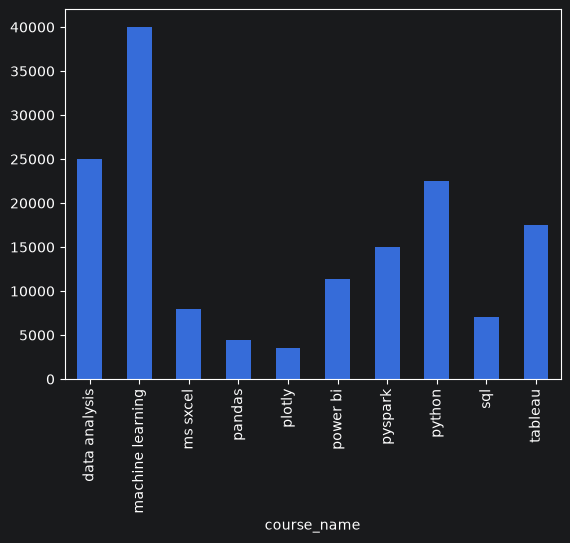

In [5]:
print(regs.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar'))

Question 5. Find students who enrolled in both the months

In [6]:
common_student_id = np.intersect1d(nov['student_id'],dec['student_id'])
print(common_student_id)

[ 1  3  7 11 16 17 18 22 23]


Question 6. find course that got no enrollment

courses['course_id']

regs['course_id']

In [7]:
course_id_list = np.setdiff1d(courses['course_id'],regs['course_id'])
print(courses[courses['course_id'].isin(course_id_list)])

    course_id course_name  price
10         11       Numpy    699
11         12         C++   1299


Question 7. Find students who did not enroll into any courses

In [4]:
student_id_list = np.setdiff1d(students['student_id'],regs['student_id'])
print(students[students['student_id'].isin(student_id_list)].shape[0])

7


Question 8. Print student name -> partner name for all enrolled students

In [5]:
# self join
print(students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']])

                name_x              name_y
0        Kailash Harjo      Chhavi Lachman
1          Esha Butala       Kailash Harjo
2       Parveen Bhalla      Parveen Bhalla
3          Marlo Dugal    Pranab Natarajan
4          Kusum Bahri  Lakshmi Contractor
5   Lakshmi Contractor      Aayushman Sant
6         Tarun Thaker   Nitika Chatterjee
7       Radheshyam Dey         Kusum Bahri
8    Nitika Chatterjee         Marlo Dugal
9       Aayushman Sant      Radheshyam Dey
10  David Mukhopadhyay       Hanuman Hegde
11          Radha Dutt        Qabeel Raman
12      Munni Varghese        Radhika Suri
13    Pranab Natarajan          Yash Sethi
14           Preet Sha        Elias Dodiya
15        Elias Dodiya     Shashank D’Alia
16        Yasmin Palan        Tarun Thaker
17     Fardeen Mahabir      Munni Varghese
18        Qabeel Raman          Radha Dutt
19       Hanuman Hegde  David Mukhopadhyay
20          Seema Kota           Preet Sha
21          Yash Sethi          Seema Kota
22      Chh

Question 9. Find top 3 students who did most number enrollments

In [6]:
print(regs.merge(students,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3))

student_id  name            
23          Chhavi Lachman      6
7           Tarun Thaker        5
14          Pranab Natarajan    4
Name: name, dtype: int64


Question 10. Find top 3 students who spent most amount of money on courses

In [7]:
print(regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3))

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64
